# Program - cn_pt

**Purpose**

Read TaiESM hindcast simulation data. Given a variable and lat/lon, plot time-pressure cross-section.

**Content**
- Read TaiESM hindcast data at a grid point (lat, lon)
- Interpolate the data on the same pressure levels
- Set tick marks for time
- Adjust contour levels and color bar according to the variables
- Make cn_pt plots, using either contourf (smoothed coutour) or pcolormesh (pixeled contour)

**Author:** Yi-Hsuan Chen (yihsuan@umich.edu)

**Date:** 

**Reference program:**



In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np
import xarray as xr
import io, os, sys, types

import yhc_module as yhc
#import read_data as read_data   ## on GFDL PP/AN
import read_data_big as read_data    ## on my Mac

#--- silence dask large chunk and silence the warning.
import dask
dask.config.set(**{'array.slicing.split_large_chunks': False})

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation

ERROR 1: PROJ: proj_create_from_database: Open of /lfs/opt/anaconda3/share/proj failed


In [45]:
def get_config_values(config, defaults):
    return {key: config.get(key, defaults[key]) for key in defaults}

# Default values
default_values = {
    "v1": 1,
    "v2": None,
    "v3": "ggg",
    "v4": 3.4,
}

# Inside func1
def func1(a, b, c, config):
    values = get_config_values(config, default_values)
    v1, v2, v3, v4 = values["v1"], values["v2"], values["v3"], values["v4"]

    print(f"v1={v1}, v2={v2}, v3={v3}, v4={v4}")

config = {
    "v1": 5,
    "v2": None,
    "v3": "aaa",
}
func1(1, 2, 3, config)



v1=5, v2=None, v3=aaa, v4=3.4


# Functions

## ----- read data -----

## select_region_ds

In [2]:
##################
##################
##################
def select_region_ds(ds,
                  region="lat_lon",
                  lat=None, lon=None, 
                 ):

    func_name = "select_ds_region"
    
    #--- given the lat/lon range of a region
    if (region == "NE_CA"):
        #lowerlon=235; upperlon=245; lowerlat=28; upperlat=35
        lowerlon=225; upperlon=250; lowerlat=24; upperlat=40

    elif (region == "DYCOMS"): 
        #--- reference: Eyeballing in Fig. 1 in Stevens et al. (2007, MWR)
        region_name = "DYCOMS (29.5-33N, 120-123.5W)"
        lowerlat =  29.5   # 29.5N
        upperlat =  33     # 33N
        lowerlon =  236.5  # 123.5W
        upperlon =  240    # 120W

    elif (region == "lat_lon"): 
        if lat is None or lon is None:
            error_msg = f"ERROR: function [{func_name}] needs lat [{lat}] and lon [{lon}] when region='lat_lon'"
            raise KeyError(error_msg)
    
    else:
        lowerlon=-1000; upperlon=1000; lowerlat=-1000; upperlat=1000

    #--- select for in the given region
    if (region == "lat_lon"):
        lat_index, lon_index = get_lat_lon_indexes(ds, lat, lon)
        ds_region = ds.isel(lat=lat_index, lon=lon_index)

    else:
        lon_slice = slice(lowerlon, upperlon)
        lat_slice = slice(lowerlat, upperlat)
        ds_region = ds.sel(lat=lat_slice, lon=lon_slice)
    
    return ds_region

##################
##################
##################
def get_lat_lon_indexes(ds, lat, lon):
    lat_index = abs(ds['lat'] - lat).argmin().item()
    lon_index = abs(ds['lon'] - lon).argmin().item()

    return lat_index, lon_index

#-----------
# do_test
#-----------

do_test="112"
#do_test=False

if (do_test == "111"):
    choice = "custom_Ttend_3hr"
    icdate = "20010710"
    ds1 = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=5)
    
    lat=31.5 ; lon=236.5
    
    ds1_region = select_region_ds(ds1, region="lat_lon", lat=lat, lon=lon)

#ds1_region

## read_hindcast_icdate_lat_lon

In [3]:
def read_hindcast_icdate_lat_lon(icdate, 
    lat=31.5, lon=236.5,
    ):

    file_dates = 5

    #--- read datasets
    choice = "custom_Ttend_3hr"
    ds_Ttend = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=file_dates)

    choice = "custom_state_3hr"
    ds_state = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=file_dates)

    choice = "custom_Qtend_3hr"
    ds_Qtend = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=file_dates)

    choice = "custom_2d_1hr"
    ds_2d = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=file_dates)

    #--- diagnose variables in all ds
    yhc.diagnose_var(ds_state, ["play"])
    yhc.diagnose_var(ds_Ttend, ["DT_SUM_PHYS", "DT_deep"])
    yhc.diagnose_var(ds_Qtend, ["DQV_SUM_PHYS", "DQL_SUM_PHYS", "DQV_deep"])

    #--- get data at the given lat/lon
    ds_Ttend_latlon = select_region_ds(ds_Ttend, region="lat_lon", lat=lat, lon=lon)
    ds_Qtend_latlon = select_region_ds(ds_Qtend, region="lat_lon", lat=lat, lon=lon)
    ds_state_latlon = select_region_ds(ds_state, region="lat_lon", lat=lat, lon=lon)
    ds_1d_time_latlon = select_region_ds(ds_2d, region="lat_lon", lat=lat, lon=lon)

    return ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon, ds_1d_time_latlon

#-----------
# do_test
#-----------

do_test="112"
#do_test=False

if (do_test == "111"):
    icdate = "20010710"
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon, ds_1d_time_latlon = read_hindcast_icdate_lat_lon(icdate)

#ds_state_latlon
#ds_Ttend_latlon
#ds_Qtend_latlon
#ds_1d_time_latlon

## get_ds_time_level_2d_vars_for_xy_plot

In [4]:
import cftime

###############
###############
###############
class read_hindcast_data:
    def __init__(self, icdate, lat, lon):
        """
        Initialize the object with initial datasets based on the provided initial conditions (icdate), 
        latitude (lat), and longitude (lon).
        
        Args:
        - icdate: The initial condition date for the hindcast (string or datetime)
        - lat: Latitude coordinate for the data (float)
        - lon: Longitude coordinate for the data (float)
        """
        self.datasets = {}  # Store datasets in a dictionary
        self.load_data(icdate, lat, lon)  # Load initial datasets

    def load_data(self, icdate, lat, lon):
        """
        Load datasets dynamically using the given initial condition date, latitude, and longitude. 
        The datasets are retrieved and stored in the `self.datasets` dictionary.
        
        Args:
        - icdate: The initial condition date for the hindcast (string or datetime)
        - lat: Latitude coordinate for the data (float)
        - lon: Longitude coordinate for the data (float)
        """
        try:
            # Retrieve data from the hindcast based on the given initial conditions
            ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon, ds_1d_time_latlon = read_hindcast_icdate_lat_lon(icdate, lat=lat, lon=lon)
            
            # Store the datasets in the dictionary
            self.datasets["ds_state"] = ds_state_latlon  # Main state dataset
            self.datasets["ds_Ttend"] = ds_Ttend_latlon  # Temperature tendency dataset
            self.datasets["ds_Qtend"] = ds_Qtend_latlon  # Q tendency dataset
            self.datasets["ds_1d_time"] = ds_1d_time_latlon  # Q tendency dataset
            self.datasets["play"] = ds_state_latlon["play"]  # Play variable from state dataset
            self.datasets["Z3"] = ds_state_latlon["Z3"]  # Store "Z3" from state dataset

            # add new attributes
            self.datasets["play"].attrs["coord_label"] = "Pressure (hPa)"
            self.datasets["play"].attrs["do_inverse_yaxis"] = True

            self.datasets["Z3"].attrs["coord_label"] = "Altitude (m)"
            self.datasets["Z3"].attrs["do_inverse_yaxis"] = False
        
        except Exception as e:
            print(f"Error loading data: {e}")  # Error handling if data loading fails
            self.datasets = {}  # Reset the datasets in case of an error

    def get(self, data):
        """
        Retrieve a specific dataset by name.

        Args:
        - data: The name of the dataset to retrieve (string)
        
        Returns:
        - The requested dataset or None if the dataset is not found.
        """
        return self.datasets.get(data, None)

    def set(self, key, value):
        """
        Modify or add a dataset to the dictionary dynamically.

        Args:
        - key: The name of the dataset (string)
        - value: The dataset value (object)
        """
        self.datasets[key] = value  # Add or update the dataset in the dictionary

###############
###############
###############
def select_ds_time_period(ds_dict, lev_dict, start_str=None, end_str=None):
    """
    Selects data from a dictionary of xarray Datasets within a specified time period.

    Parameters:
        ds_dict (dict): A dictionary of xarray Datasets, where each dataset contains a 'time' coordinate in cftime.DatetimeNoLeap format.
        start_str (str): Start time in "YYYYMMDD_HHMMSS" format.
        end_str (str): End time in "YYYYMMDD_HHMMSS" format.

    Returns:
        dict: A dictionary of xarray Datasets within the specified time range.
    """

    # Assuming all datasets in ds_dict have the same time range, get the global time range from one of them
    time_min, time_max = ds_dict[next(iter(ds_dict))].time.min().item(), ds_dict[next(iter(ds_dict))].time.max().item()

    # Check if the start_str and end_str are provided
    if start_str:
        # Parse start time from "YYYYMMDD_HHMMSS" format
        start_time = cftime.DatetimeNoLeap(
            int(start_str[:4]),  # Year
            int(start_str[4:6]),  # Month
            int(start_str[6:8]),  # Day
            int(start_str[9:11]),  # Hour
            int(start_str[11:13]),  # Minute
            int(start_str[13:15])   # Second
        )

        # Validate start_time within dataset range
        if start_time < time_min or start_time > time_max:
            raise ValueError(f"start_str ({start_str}) is out of range: {time_min} to {time_max}")
    else:
        start_time = time_min  # Default to minimum time in dataset if start_str is not provided

    if end_str:
        # Parse end time from "YYYYMMDD_HHMMSS" format
        end_time = cftime.DatetimeNoLeap(
            int(end_str[:4]),  # Year
            int(end_str[4:6]),  # Month
            int(end_str[6:8]),  # Day
            int(end_str[9:11]),  # Hour
            int(end_str[11:13]),  # Minute
            int(end_str[13:15])   # Second
        )

        # Validate end_time within dataset range
        if end_time < time_min or end_time > time_max:
            raise ValueError(f"end_str ({end_str}) is out of range: {time_min} to {time_max}")
    else:
        end_time = time_max  # Default to maximum time in dataset if end_str is not provided

   # Check if end_time is greater than start_time
    if end_time < start_time:
        raise ValueError(f"end_time ({end_time}) cannot be earlier than start_time ({start_time})")
        
    # Apply the time selection to each dataset in the dictionary and return the updated dictionary
    ds_dict_filtered = {key: ds.sel(time=slice(start_time, end_time)) for key, ds in ds_dict.items()}
    lev_dict_filtered = {key: lev.sel(time=slice(start_time, end_time)) for key, lev in lev_dict.items()}

    return ds_dict_filtered, lev_dict_filtered

###############
###############
###############
def select_lev_range(ds_dict, lev_dict, lev_select=None, lev_min=None, lev_max=None):
    """
    Filters datasets within a specified lev range based on a selected variable from lev_dict.

    Parameters:
        ds_dict (dict): Dictionary containing the datasets (e.g., 'ds_state', 'ds_Ttend').
        lev_dict (dict): Dictionary containing the variables like 'play', 'Z3'.
        lev_select (str): Select which variable from lev_dict to use ('play' or 'Z3').
        lev_min (float): Minimum lev value for filtering.
        lev_max (float): Maximum lev value for filtering.

    Returns:
        tuple: Filtered ds_dict and lev_dict.
    """

    if lev_min is not None and lev_max is not None:
        # Check which variable to use for filtering
        if lev_select == "play":
            mask = (lev_dict["play"] > lev_min) & (lev_dict["play"] < lev_max)
        elif lev_select == "Z3":
            mask = (lev_dict["Z3"] > lev_min) & (lev_dict["Z3"] < lev_max)
        else:
            raise ValueError(f"Invalid lev_select value: {lev_select}. Must be 'play' or 'Z3'.")
        
        # Compute the mask if it's a dask array
        mask_computed = mask.compute()  # Eager evaluation
    
        # Get lev indices where the condition is True across all time points
        lev_indices = mask_computed.any(dim='time')  # Boolean array (lev,) for condition across all time
    
        # Extract the lev values that match the condition
        lev_values_to_select = lev_dict["play"].lev.values[lev_indices]  # Get lev values from play or Z3
    
        # Apply filtering to the datasets using the lev values
        ds_dict_filtered = {key: val.sel(lev=lev_values_to_select) for key, val in ds_dict.items()}
        lev_dict_filtered = {key: val.sel(lev=lev_values_to_select) for key, val in lev_dict.items()}
    
        return ds_dict_filtered, lev_dict_filtered
    else:
        return ds_dict, lev_dict

###############
###############
###############
def get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon,
                                         lev_select=None, lev_min=None, lev_max=None,
                                         start_str=None, end_str=None,
                                         ):
    """
    Retrieve datasets containing variables with 2D dimensions [time, level] for use in XY plots.
    The function returns datasets for key variables such as state, Ttend, Qtend, and other related variables 
    like play and Z3.

    Args:
    - icdate: The initial condition date for the hindcast (string or datetime)
    - lat: Latitude coordinate for the data (float)
    - lon: Longitude coordinate for the data (float)

    Returns:
    - ds_dict: Dictionary containing the primary datasets (state, Ttend, Qtend)
    - lev_dict: Dictionary containing additional variables for XY plot (play, Z3)
    """
    # Create an instance of the read_hindcast_data class
    hindcast_data = read_hindcast_data(icdate, lat, lon)

    # Retrieve the datasets for main variables
    ds_dict = {
        "state": hindcast_data.get("ds_state"),  # Main state dataset
        "Ttend": hindcast_data.get("ds_Ttend"),  # Temperature tendency dataset
        "Qtend": hindcast_data.get("ds_Qtend"),  # Q tendency dataset
        "1d_time": hindcast_data.get("ds_1d_time"),  # time series dataset
    }

    # Additional variables for XY plot
    lev_dict = {
        "play": hindcast_data.get("play"),  # Play variable for plotting
        "Z3": hindcast_data.get("Z3"),  # Z3 variable for plotting
    }

    # select level range
    ds_dict, lev_dict = select_lev_range(ds_dict, lev_dict, lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

    # select time range
    ds_dict, lev_dict = select_ds_time_period(ds_dict, lev_dict, start_str=start_str, end_str=end_str)

    return ds_dict, lev_dict

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"
    lat = 31.5
    lon = 236.5
    
    # select all time and lev
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon)

    # select lev range
    lev_select = "Z3" ; lev_max = 3000 ; lev_min = 1000
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
                                                            lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

    # select time range
    start_str = "20010711_000000"
    end_str = "20010713_000000"
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
                                                             start_str=start_str, end_str=end_str)

    # select both time and lev range
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
                                                             lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
                                                             start_str=start_str, end_str=end_str)
#ds_dict['1d_time']
#lev_dict['Z3']
#lev_dict['play']


## ----- shared for cn and xy plots -----

## create_time_coord_labels

In [16]:
def create_time_coord_labels(ds, time_interval):
    
    # Convert time to numeric values (0 to len(time))
    time_numeric = np.arange(len(ds["time"].values))

    # Set the x-axis ticks and labels for time
    time_ticks = np.arange(0, len(time_numeric), time_interval)
    time_labels = [t.strftime('%m%d_%H') for t in ds["time"].isel(time=time_ticks).values]

    return time_numeric, time_ticks, time_labels

#-----------
# do_test
#-----------

time_interval = 3
#time_numeric, time_ticks, time_labels = create_time_coord_labels(ds_dict['state'], time_interval=time_interval)

#print(time_numeric)
#print(time_ticks)
#print(time_labels)
#ds_dict['state']

## generate_plot_xy_kwargs

In [17]:
################
################
################
def separate_var_dict(var_dict, default_style):
    """
    Separates the variable dictionary into two dictionaries:
    - One containing plot styling attributes ('color', 'marker', 'linestyle').
    - One containing other attributes (e.g., 'label').

    If 'color', 'marker', or 'linestyle' are missing, default values are assigned.

    Parameters:
    var_dict (dict): Dictionary mapping variable names to their plotting attributes.

    Returns:
    tuple: (dict with styling attributes, dict with other attributes)
    """
    style_keys = {'color', 'marker', 'linestyle'}  # Keys related to plot styles
    
    # Default style settings
    #default_style = {
    #    'color': 'blue',     # Default color
    #    'marker': 'x',        # Default marker
    #    'linestyle': '-'      # Default linestyle
    #}
    
    style_dict = {}  # Dictionary for color, marker, linestyle
    meta_dict = {}   # Dictionary for other attributes

    for var, attrs in var_dict.items():
        # Extract style-related attributes and apply defaults where necessary
        style_dict[var] = {k: attrs.get(k, default_style[k]) for k in style_keys}
        
        # Extract metadata attributes (anything not in style_keys)
        meta_dict[var] = {k: v for k, v in attrs.items() if k not in style_keys}

    return style_dict, meta_dict

################
################
################
def generate_plot_xy_kwargs(var_name, da, var_list, option_default=None):
    """
    Generate plot styling and metadata dictionaries for a given variable.
    
    Parameters:
    var_name (str): The primary variable name.
    da (xarray.DataArray): DataArray object to extract metadata.
    var_list (list): List of variable names.
    
    Returns:
    tuple: (style_dict, meta_dict) for the given var_name.
    """

    # Define colors for different processes
    #  
    #    * Line colors, https://matplotlib.org/stable/gallery/color/named_colors.html
    #        red (r), blue (b), green (g), cyan (c), magenta (m), yellow (y), black (k), white (w)
    #
    #.   * Line dash pattern, https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html
    #.       {'-', '--', '-.', ':'} {solid, dashed, dashdot, dotted}
    #
    #.   * Markers, https://matplotlib.org/stable/api/markers_api.html
    #        {'.', 'o', '^', 's'} = {point, circle, triangle_up, square}  

    color_tot = 'black' ; color_dyn = 'darkgray' ; color_PT = 'red' ; color_sum = color_PT
    color_ZM = 'blue'   ; color_CMF = 'cyan'     ; color_DPDLF = 'royalblue' ; color_SHDLF = 'skyblue'
    color_MACP = 'green' ; color_MP = 'limegreen' ; color_QRL = 'orange' ; color_QRS = 'pink' 
    color_vdiff = 'purple' ; color_gwd = 'yellow'
    
    color_cyan = 'c' ; color_red = 'r' 
    
    # Define style and metadata information
    var_dict = {
        #--- T tendency 
        'TTEND_TOT': {'color': color_tot, 'label': 'Total=dyn+phys [TTEND_TOT]'},
        'DTCORE': {'color': color_dyn, 'label': 'Dynamics [DTCORE]'},
        'PTTEND': {'color': color_PT, 'label': 'All phys [PTTEND]'},
        'DT_deep': {'color': color_ZM, 'label': 'Deep convection [ZMDT+ZMMTT+EVAPTZM]'},
        'CMFDT': {'color': color_CMF, 'label': 'Shallow convection [CMFDT]'},
        'DPDLFT': {'color': color_DPDLF, 'label': 'Deep conv detrain [DPDLFT]'},
        'SHDLFT': {'color': color_SHDLF, 'label': 'Shallow conv detrain [SHDLFT]'},
        'MACPDT': {'color': color_MACP, 'label': 'Macrophysics [MACPDT]'},
        'MPDT': {'color': color_MP, 'label': 'Microphysics [MPCT]'},
        'QRL': {'color': color_QRL, 'label': 'LW radiation [QRL]'},
        'QRS': {'color': color_QRS, 'label': 'SW radiation [QRS]'},
        'DTV': {'color': color_vdiff, 'label': 'PBL & turbulence [DTV]'},
        'TTGWORO': {'color': color_gwd, 'label': 'grav wave drag [TTGWORO]'},
        'DT_SUM_PHYS': {'color': color_sum, 'label': 'Sum of all phys tend', 'linestyle': '--'},

        #--- QV tendency 
        'QVTEND_TOT': {'color':color_tot, 'label': 'Total=dyn+phys [QVTEND_TOT]'},
        'DQVCORE': {'color':color_dyn, 'label': 'Dynamics [DQVCORE]'},
        'PTEQ': {'color':color_PT, 'label': 'All phys [PTEQ]'},
        'DQV_deep': {'color': color_ZM, 'label':'Deep convection [ZMDQ+EVAPQZM]'},
        'ZMDQ': {'color': color_ZM, 'label':'Deep convection [ZMDQ]'},
        'EVAPQZM': {'color': color_ZM, 'label':'Evap from deep conv [EVAPQZM]', 'linestyle': '--'},
        'CMFDQ': {'color': color_CMF, 'label': 'Shallow convection [CMFDLIQ]'},
        'MACPDQ': {'color':color_MACP, 'label':'Macrophysics [MACPDQ]'},
        'MPDQ': {'color':color_MP, 'label':'Microphysics [MPDQ]'},
        'VD01': {'color':color_vdiff, 'label': 'PBL & turbulence [VD01]'},
        'DQV_SUM_PHYS': {'color':color_sum, 'label': 'Sum of all phys tend', 'linestyle':'--'},

        #--- QL tendency 
        'QLTEND_TOT': {'color':color_tot, 'label': 'Total=dyn+phys [QLTEND_TOT]'},
        'DQLCORE': {'color':color_dyn, 'label': 'Dynamics [DQLCORE]'},
        'PTECLDLIQ': {'color':color_PT, 'label': 'All phys [PTECLDLIQ]'},
        'ZMDLIQ': {'color': color_ZM, 'label':'Deep convection [ZMDLIQ]'},
        'CMFDLIQ': {'color': color_CMF, 'label': 'Shallow convection [CMFDLIQ]'},
        'DPDLFLIQ': {'color':color_DPDLF, 'label': 'Deep conv detrain [DPDLFLIQ]'},
        'SHDLFLIQ': {'color':color_SHDLF, 'label':'Shallow conv detrain [SHDLFLIQ]'},
        'MACPDLIQ': {'color':color_MACP, 'label':'Macrophysics [MACPDLIQ]'},
        'MPDLIQ': {'color':color_MP, 'label':'Microphysics [MPDLIQ]'},
        'VDCLDLIQ': {'color':color_vdiff, 'label': 'PBL & turbulence [VDCLDLIQ]'},
        'DQL_SUM_PHYS': {'color':color_sum, 'label': 'Sum of all phys tend', 'linestyle':'--'},

        #--- QI tendency
        'QITEND_TOT': {'color':color_tot, 'label': 'Total=dyn+phys [QITEND_TOT]'},
        'DQICORE': {'color':color_dyn, 'label': 'Dynamics [DQICORE]'},
        'PTECLDICE': {'color':color_PT, 'label': 'All phys [PTECLDICE]'},
        'ZMDICE': {'color': color_ZM, 'label':'Deep convection [ZMDICE]'},
        'CMFDICE': {'color': color_CMF, 'label': 'Shallow convection [CMFDICE]'},
        'DPDLFICE': {'color':color_DPDLF, 'label': 'Deep conv detrain [DPDLFICE]'},
        'SHDLFICE': {'color':color_SHDLF, 'label':'Shallow conv detrain [SHDLFICE]'},
        'MACPDICE': {'color':color_MACP, 'label':'Macrophysics [MACPDICE]'},
        'MPDICE': {'color':color_MP, 'label':'Microphysics [MPDICE]'},
        'VDCLDICE': {'color':color_vdiff, 'label': 'PBL & turbulence [VDCLDICE]'},
        'DQI_SUM_PHYS': {'color':color_sum, 'label': 'Sum of all phys tend', 'linestyle':'--'},
        
        #--- precipitation
        'PRECC': {'color': 'b', 'label': 'Convective precip'},
        'PRECL': {'color': 'c', 'label': 'Large-scale precip'},
    }

    # Default style for unknown variables
    if (option_default == "xy_profile_1tNv"):
        default_style = {'color': 'blue', 'marker': '.', 'linestyle': '-'}
    elif (option_default == "xy_profile_1vNt"):
        default_style = {'color': 'blue', 'marker': '.', 'linestyle': '-'}
    else:
        default_style = {'color': 'blue', 'marker': None, 'linestyle': '-'}

    # Extract metadata from DataArray
    long_name = getattr(da, "long_name", None)
    units = getattr(da, "units", None)
    
    # Determine xlabel based on the number of variables
    if len(var_list) == 1:
        var_label = f"{long_name} ({units})" if long_name and units else long_name or units or var_name
    elif isinstance(var_list, str):
        var_label = f"{long_name} ({units})" if long_name and units else long_name or units or var_name
    else:
        var_label = units if units else var_name  # Ensure var_label is always assigned
    
    # Default metadata
    default_meta = {'label': var_name, 'var_label': var_label}

    # Separate style and metadata attributes
    style_dict, meta_dict = separate_var_dict(var_dict, default_style)

    # Retrieve style and metadata for the given var_name
    style = style_dict.get(var_name, default_style)
    meta = meta_dict.get(var_name, default_meta)

    # Ensure xlabel is included in the meta_dict
    meta['var_label'] = var_label
    if 'label' not in meta:
        meta['label'] = var_name  # Ensure 'label' is always present in meta

    return style, meta

## generate_cn_kwargs

In [18]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

################
################
################
def generate_cn_kwargs(var: xr.DataArray, var_name: str):
    """
    Get plot settings (cmap, levels, long_name, units, and cbar_label) for a given variable.

    Parameters:
    - var: xarray.DataArray
        The variable to be plotted.
    - var_name: str
        The name of the variable.

    Returns:
    - settings: dict
        A dictionary with plot settings for the given variable.
    """
    # Default settings in case attributes are missing
    default_settings = {
        "cmap": "viridis",
        "levels": None,  # Will be determined dynamically if possible
        "norm": None, 
        "norm_option": None, 
        "long_name": var_name,  # Use var_name if long_name is missing
        "units": "Unknown Units",
        "cbar_label": f"{var_name} (Unknown Units)"
    }

    # Predefined variable settings (can be extended)
    ttend_min = -30 ; ttend_max = 20 ; ttend_num_levels = 11
    variable_settings = {
        "TTEND_TOT": {"cmap": "RdBu_r", 
                      #"levels":np.linspace(ttend_min, ttend_max, ttend_num_levels) ,
                      #"norm": mcolors.TwoSlopeNorm(vmin=ttend_min, vcenter=0, vmax=ttend_max),
                      "norm_option" : "auto", 
                     },
        "QVTEND_TOT": {"cmap": "BrBG", 
                       "norm_option" : "auto", 
                      },
        "QLTEND_TOT": {"cmap": "BrBG", 
                       "norm_option" : "auto", 
                      },
        "T": {"cmap": "coolwarm"},
        "Q": {"cmap": "YlGnBu"},
        "CLDLIQ": {"cmap": "viridis"},
        "P": {"cmap": "RdBu"}
    }
    
    # Extract attributes
    long_name = var.attrs.get("long_name", default_settings["long_name"])
    units = var.attrs.get("units", default_settings["units"])

    # Determone cmap, levels, and norm
    cmap, levels, norm = get_cmap_levels_norm (var_name, variable_settings, default_settings, var)
    
    if var_name in ["MPDT", "MACPDT", "DTV", "DT_SUM_PHYS", "DTCORE", "PTTEND"]:
        cmap, levels, norm = get_cmap_levels_norm ("TTEND_TOT", variable_settings, default_settings, var)  
    elif var_name in ["PTEQ", "MACPDQ", "MPDQ", "VD01", "DQVCORE", "DQV_SUM_PHYS"]:
        cmap, levels, norm = get_cmap_levels_norm ("QVTEND_TOT", variable_settings, default_settings, var)
    elif var_name in ["PTECLDLIQ", "MACPDLIQ", "MPDLIQ", "VDCLDLIQ", "DQLCORE", "DQL_SUM_PHYS"]:
        cmap, levels, norm = get_cmap_levels_norm ("QLTEND_TOT", variable_settings, default_settings, var)
    
    # Construct colorbar label
    cbar_label = f"{long_name} ({units})"

    return {
        "norm":norm, 
        ###
        "cmap": cmap,
        "levels": levels,
        "long_name": long_name,
        "units": units,
        "cbar_label": cbar_label
    }

################
################
################
def get_nice_contour_levels(var_data, num_levels=15):
    if np.issubdtype(var_data.dtype, np.number):  # Ensure it's numeric
        vmin, vmax = np.nanmin(var_data), np.nanmax(var_data)

        # Round vmin/vmax based on magnitude
        magnitude = 10 ** np.floor(np.log10(vmax - vmin))  # Order of magnitude
        vmin = np.floor(vmin / magnitude) * magnitude
        vmax = np.ceil(vmax / magnitude) * magnitude

        # Use MaxNLocator to find nice levels
        locator = mticker.MaxNLocator(nbins=num_levels - 1, steps=[1, 2, 2.5, 5, 10])
        levels = locator.tick_values(vmin, vmax)
    else:
        levels = default_settings["levels"]  # Use default if non-numeric

    return levels

################
################
################
def get_cmap_levels_norm(var_name, variable_settings, default_settings, var=None):
    """
    Retrieve colormap, contour levels, and norm settings for a given variable.

    Parameters:
        var_name (str): Name of the variable.
        variable_settings (dict): Dictionary with variable-specific settings.
        default_settings (dict): Dictionary with default settings.
        var (xarray.DataArray or numpy array, optional): Data array for computing levels dynamically.

    Returns:
        tuple: (cmap, levels, norm)
    """
    # Determine colormap
    cmap = variable_settings.get(var_name, {}).get("cmap", default_settings["cmap"])
    
    # Determine contour levels
    levels = variable_settings.get(var_name, {}).get("levels", default_settings["levels"])
    if levels is None and var is not None:
        var_data = var.values
        levels = get_nice_contour_levels(var_data)

    # Determine norm
    norm_option = variable_settings.get(var_name, {}).get("norm_option", default_settings["norm_option"])
    if norm_option == "auto":
        norm = mcolors.TwoSlopeNorm(vmin=np.min(levels), vcenter=0, vmax=np.max(levels))
    else:
        norm = variable_settings.get(var_name, {}).get("norm", default_settings["norm"])

    return cmap, levels, norm

## get_plot_opt

In [77]:
# Default values
opt_default_values = {
    "lev_select": "play", "lev_min": None, "lev_max": None,
    "start_str": None, "end_str": None, 
    "title": None, 

    #--- for cn_time_lev and xy_series plots
    "time_tick_major_interval":8, "time_tick_minor_number":3 ,

    #--- for xy_profile_1vNt plots
    "stride": 8, 
}

#################
def get_opt_values(opt, defaults):
    return {key: opt.get(key, defaults[key]) for key in defaults}

#################
def get_plot_opt(opt_in):
    opt_out = get_config_values(opt_in, opt_default_values)
    return opt_out

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    opt_in = {
        "lev_min": 800,
        "lev_max": 1000,
        "time_tick_major_interval": 100
    }    

    opt_out = get_plot_opt(opt_in)
    print(opt_out)
    #print(opt_out['lev_min'])

## (Not used) plot_xy_figs_panel

In [19]:
def plot_xy_figs_panel (ds_dict, lev_dict, var_src_names, option, 
                        time_interval=1, # input arguments for option="xy_series_Nv"
                        play_pt=None, date_selected=None, 
                        title=None):
    """
    Creates a panel plot with 2 columns and adjusts rows dynamically based on var_src_names.

    Parameters:
        ds_dict (dict): Dictionary containing dataset objects with keys as dataset names.
        var_src_names (list): List of tuples (dataset_key, variable_name) to plot.
        play_pt: Additional parameter passed to plot_time_lev_contour.
    """

    func_name = "plot_xy_figs_panel"
    
    num_vars = len(var_src_names)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing

    # plot
    if (option == "xy_series_Nv"):
        for i, (ds_key, var_list) in enumerate(var_src_names):
            plot_xy_series_Nv(axes[i], ds_dict[ds_key], var_list, time_interval=time_interval, title=title)

    elif (option == "ddd"):
        for i, (ds_key, var_name) in enumerate(var_src_names):
            plot_xy_profile_Nv(axes[i], ds_dict[ds_key], play_pt, var_name, date_selected, title=title)  

    else:
        raise ValueError(f"ERROR: in func [{func_name}]: option=[{option}] is not supported. STOP.")
    
    # Remove extra unused subplots
    for j in range(len(var_src_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()


## ----- xy_series, N variables -----

## plot_xy_series_Nv

In [21]:
import warnings

def plot_xy_series_Nv(ax, ds, var_list, time_interval=1, title=None):

    func_name = "plot_xy_series_Nv"

    for var_name in var_list:
        if var_name in ds:
            time_numeric, time_ticks, time_labels = create_time_coord_labels(ds, time_interval=time_interval)
            var_1d_time = yhc.unit_convert(ds[var_name][:])
            units = getattr(var_1d_time, "units", " ")            
            style, meta = generate_plot_xy_kwargs(var_name, var_1d_time, var_list)
            ax.plot(time_numeric, var_1d_time, label=meta["label"], **style)
            #print('bb02')
            #print(time_numeric)
            #print(var_1d_time)
        else:
            warnings.warn(f"func [{func_name}]: Variable '{var_name}' not found in the dataset.", UserWarning)

    # Set the x-axis ticks and labels for time
    ax.set_xlim(np.min(time_numeric), np.max(time_numeric))
    ax.set_xticks(time_ticks)
    ax.set_xticklabels(time_labels)
        
    ax.set_xlabel("Time")
    ax.set_ylabel(meta["var_label"])

    right_string = f"{units}"
    left_string  = f"aaa"
    #ax.text(0, 1.05, left_string, transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(1, 1.05, right_string, transform=ax.transAxes, fontsize=12, horizontalalignment='right', verticalalignment='top')

    if title is not None:
        ax.set_title(title, y=1.05)

    ax.legend()
    ax.grid()
    
    # Add tick marks on the top and right side
    ax.tick_params(axis='both', which='both', direction='out', length=2)  # This adds ticks to both axes
    ax.tick_params(axis='x', which='both', top=True)  # Ticks on the top
    ax.tick_params(axis='y', which='both', right=True)  # Ticks on the right

    ax.minorticks_on()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"
    lat = 31.5
    lon = 236.5
    
    # select all time and lev
    ds_dict, yy_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon)

    fig, ax = plt.subplots()
    var_list = ["PRECC","PRECL"]
    #var_list = ["FSNS","FLNS"]
    title="aaa"

    plot_xy_series_Nv(ax, ds_dict['1d_time'], var_list, time_interval=24, title=title)

## plot_xy_series_Nv_panel

In [22]:
def plot_xy_series_Nv_panel(icdate, lat, lon, var_group, 
                            start_str=None, end_str=None, 
                            lev_select=None, lev_min=None, lev_max=None, 
                            time_interval=1,
                            title=None):  
    """
    Plots time series data for selected variables at a given location (lat, lon) and initialization date (icdate).
    
    Parameters:
        icdate (str): Initialization date of the dataset.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        var_group (str or list): Variable group to plot; can be predefined group names or a list of variable names.
        start_str (str, optional): Start time string for data selection.
        end_str (str, optional): End time string for data selection.
        lev_select (list, optional): Specific levels to extract.
        lev_min (float, optional): Minimum level to extract.
        lev_max (float, optional): Maximum level to extract.
        time_interval (int, optional): Time interval for plotting. Defaults to 1.
    """

    func_name = "plot_xy_series_Nv_panel"  # Function name for reference (unused)

    # Retrieve dataset and vertical level information for the specified location and time range
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(
        icdate, lat, lon, 
        lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
        start_str=start_str, end_str=end_str
    )

    # Define variable names for plotting based on the selected var_group
    if var_group == "state":
        var_src_names = [ 
            ("1d_time", ["PRECC", "PRECL"]),  # Precipitation components
            ("1d_time", ["FSNS"])             # Surface net shortwave flux
        ]
        
    elif var_group == "test":
        var_src_names = [ 
            ("1d_time", ["PRECC", "PRECL"]),   
            ("1d_time", ["FSNS"]),
            ("1d_time", ["TGCLDLWP"]),      
        ]
    else:
        var_src_names = var_group
        #var_src_names = [ 
        #    ("1d_time", var_group)            # Use the provided variable group directly
        #]

    # set columns and rows
    num_vars = len(var_src_names)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing

    # plot
    for i, (ds_key, var_list) in enumerate(var_src_names):
        plot_xy_series_Nv(axes[i], ds_dict[ds_key], var_list, time_interval=time_interval, title=title)
    
    # Remove extra unused subplots
    for j in range(len(var_src_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()

    # Generate the plot with the selected variables and options
    #option = "xy_series_Nv"  # Plot type identifier
    #plot_xy_figs_panel(ds_dict, lev_dict, var_src_names, option=option, time_interval=time_interval, title=title)

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010709"
    lat = 31.5
    lon = 236.5

    # set variables for plotting
    var_group = "test"
    #var_group = ["PRECC","PRECL"]

    # set time
    start_str = None ; end_str=None ; time_interval = 24
    #start_str = "20010711_000000" ; end_str = "20010713_000000" ; time_interval = 12

    # set title
    lat_str = f"{lat:.2f}" ; lon_str = f"{lon:.2f}"
    title = f"icdate={icdate}, lat={lat_str}, lon={lon_str} \n hourly time series"

    # make panel plots
    plot_xy_series_Nv_panel(icdate, lat, lon, var_group,
                            time_interval=time_interval, start_str=start_str, end_str=end_str, 
                            title=title)

## ----- xy_profile: 1 time step, N variables -----

## plot_xy_profile_Nv1t

In [71]:
import warnings

def plot_xy_profile_Nv1t(ax, ds, lev_1d, var_list, title=None):
    """
    Create an XY plot for multiple variables from an xarray.Dataset as X and an xarray.DataArray as Y.
    
    Parameters:
    ds (xarray.Dataset): The dataset containing multiple variables.
    play (xarray.DataArray): The y-axis variable.
    var_list (list): List of variable names in ds to plot against play.
    ax (matplotlib.axes.Axes): The axis to plot on.
    plot_kwargs_list (list of dicts, optional): List of dictionaries of plotting keyword arguments for each variable.
    
    Returns:
    None
    """

    func_name = "plot_xy_profile_1tNv"
    
    for var_name in var_list:
        if var_name in ds:
            var_1d_lev_1t = yhc.unit_convert(ds[var_name].isel(time=0))
            lev_1d_1t = lev_1d.isel(time=0)
            units = getattr(var_1d_lev_1t, "units", " ")
            style, meta = generate_plot_xy_kwargs(var_name, var_1d_lev_1t, var_list, option_default="xy_profile_1tNv")
            ax.plot(var_1d_lev_1t, lev_1d_1t, label=meta["label"], **style)
        else:
            warnings.warn(f"func [{func_name}]: Variable '{var_name}' not found in the dataset.", UserWarning)

    right_string = f"{units}"
    coord_label = getattr(lev_1d, "coord_label", None)
    left_string  = f"aaa"
    
    ax.set_xlabel(meta["var_label"])
    ax.set_ylabel(coord_label)

    #ax.text(0, 1.05, left_string, transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(1, 1.05, right_string, transform=ax.transAxes, fontsize=12, horizontalalignment='right', verticalalignment='top')
    if title is not None:
        ax.set_title(title, y=1.05)

    ax.legend()
    #ax.legend(loc="lower center")
    ax.grid()

    # Invert the y-axis to have the higher pressures at the top
    do_inverse_yaxis = getattr(lev_1d, "do_inverse_yaxis", None)
    if (do_inverse_yaxis):
        ax.invert_yaxis()
    
    # Add tick marks on the top and right side
    ax.tick_params(axis='both', which='both', direction='out', length=2)  # This adds ticks to both axes
    ax.tick_params(axis='x', which='both', top=True)  # Ticks on the top
    ax.tick_params(axis='y', which='both', right=True)  # Ticks on the right

    ax.minorticks_on()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"
    lat = 31.5
    lon = 236.5
    
    # select all time and lev
    lev_select = "play" ; lev_max = 1100 ; lev_min = 800
    #lev_select = "Z3" ; lev_max = 3000 ; lev_min = 0
    
    start_str = "20010711_000000" ; end_str = start_str

    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
                                                             lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
                                                             start_str=start_str, end_str=end_str)

    fig, ax = plt.subplots()

    var_list = ["Q"]
    plot_xy_profile_Nv1t(ax, ds_dict['state'], lev_dict[lev_select], var_list, title=None)

## plot_xy_profile_Nv1t_panel

In [75]:
def plot_xy_profile_Nv1t_panel(icdate, lat, lon, var_group, 
                               opt_in,
                              ):

    """
    Plots xy profiles data for selected variables at a given location (lat, lon) and a given time (start_str, end_str).
    
    Parameters:
        icdate (str): Initialization date of the dataset.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        var_group (str or list): Variable group to plot; can be predefined group names or a list of variable names.
        start_str (str, optional): Start time string for data selection.
        end_str (str, optional): End time string for data selection.
        lev_select (list, optional): Specific levels to extract.
        lev_min (float, optional): Minimum level to extract.
        lev_max (float, optional): Maximum level to extract.
        time_interval (int, optional): Time interval for plotting. Defaults to 1.
    """

    func_name = "plot_xy_profile_Nv1t_panel"  # Function name for reference (unused)

    # retrieve opt parameters
    opt_out = get_plot_opt(opt_in)
    lev_select = opt_out["lev_select"] ; lev_min=opt_out["lev_min"] ; lev_max=opt_out["lev_max"]
    start_str=opt_out["start_str"] ; end_str=opt_out["end_str"] ; stride=opt_out["stride"]
    title=opt_out["title"]
    
    # Retrieve dataset and vertical level information for the specified location and time range
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(
        icdate, lat, lon, 
        lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
        start_str=start_str, end_str=end_str
    )

    #--- var list
    var_list_DT_budget = ['TTEND_TOT', 'DTCORE', 'PTTEND', 'CMFDT', 'DPDLFT', 
 'SHDLFT', 'MACPDT', 'MPDT', 'QRL', 'QRS', 'DTV', 'TTGWORO', 'DT_SUM_PHYS']

    var_list_DQ_budget = ['QVTEND_TOT', 'DQVCORE', 'PTEQ', 'ZMDQ', 'EVAPQZM', 'CMFDQ', 'MACPDQ', 'MPDQ', 'VD01', 'DQV_SUM_PHYS']

    var_list_DQL_budget = [
        'QLTEND_TOT', 'DQLCORE', 'PTECLDLIQ', 'ZMDLIQ', 'CMFDLIQ', 
        'DPDLFLIQ', 'SHDLFLIQ', 'MACPDLIQ', 'MPDLIQ', 'VDCLDLIQ', 'DQL_SUM_PHYS'
    ]

    var_list_dqi_budget = [
        'QITEND_TOT', 'DQICORE', 'PTECLDICE', 'ZMDICE', 'CMFDICE', 
        'DPDLFICE', 'SHDLFICE', 'MACPDICE', 'MPDICE', 'VDCLDICE', 'DQI_SUM_PHYS'
    ]    

    #--- set var_group
    if (var_group == "T_Q_QL_tend"):
        var_src_names = [
            ("state", ["T"]),
            ("Ttend", var_list_DT_budget),
            ("state", ["Q"]),
            ("Qtend", var_list_DQ_budget),
            ("state", ["CLDLIQ"]),
            ("Qtend", var_list_DQL_budget),
        ]
        
    elif (var_group == "test"):
        var_src_names = [ 
            ("state", ["T"]),
            ("Ttend", ["TTEND_TOT", "DTCORE", "PTTEND"]),  
            ("Ttend", ["QRL", "QRS", "MPDT"]),  
            ("state", ["Q"]),
            ]
    
    else:
        var_src_names = var_group
        #raise ValueError(f"ERROR in func[{func_name}]: var_group=[{var_group}] is not supported. STOP.")

    # set columns and rows
    num_vars = len(var_src_names)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing

    # plot
    for i, (ds_key, var_list) in enumerate(var_src_names):
        plot_xy_profile_Nv1t(axes[i], ds_dict[ds_key], lev_dict[lev_select], var_list, title=title)
    
    # Remove extra unused subplots
    for j in range(len(var_src_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010709"
    lat = 31.5
    lon = 236.5

    lev_select = "play" ; lev_max = 1100 ; lev_min = 800
    #lev_select = "Z3" ; lev_max = 3000 ; lev_min = 0
    
    start_str = "20010711_000000" ; end_str = start_str

    title = f"icdate={icdate}, lat={lat_str}, lon={lon_str} \n time={start_str}"

    var_group = "test"
    plot_xy_profile_Nv1t_panel(icdate, lat, lon, var_group,
                               lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
                               start_str=start_str, end_str=end_str,
                               title=title)

## ----- xy_profile: N time steps, 1 variable -----

## plot_xy_profile_1vNt

In [25]:
import matplotlib.cm as cm

def plot_xy_profile_1vNt(ax, ds, lev_1d, var_name, 
                         cmap="rainbow", stride=1,
                         title=None,
                        ):

    """
    Plots selected time-step profiles of the specified variable in ds_nt_np against play_nt_np using Matplotlib,
    with a rainbow-like color scheme and a legend. It allows plotting every `stride`-th profile, but the colormap 
    will span all time steps, regardless of the stride.

    Parameters:
        ds_nt_np (xr.Dataset): Dataset containing the variable to plot (dimensions: [time, lev]).
        play_nt_np (xr.DataArray): DataArray used as the Y-axis values (dimensions: [time, lev]).
        var_name (str): Name of the variable in ds_nt_np to plot.
        cmap (str): Matplotlib colormap to use for color gradient (default: "rainbow").
        stride (int): The step size for selecting time profiles (default: 1, plot every profile).

    Returns:
        matplotlib.figure.Figure: The generated figure.
    """

    # Ensure the variable exists
    if var_name not in ds:
        raise ValueError(f"Variable '{var_name}' not found in dataset.")

    # Extract variable and time dimension
    var_data = yhc.unit_convert(ds[var_name])
    time_values_all = var_data.time.values  # Keep the full time range for the color map
    time_values = time_values_all[::stride]  # Slice time values based on the stride

    # Create figure and axis

    # Generate colors based on the full range of time values, independent of stride
    norm = plt.Normalize(vmin=0, vmax=len(time_values) - 1)  # Span over the full time range
    scalar_map = cm.ScalarMappable(norm=norm, cmap=cmap)

    # Create an empty list for the legend handles and labels
    handles = []
    labels = []

    # Loop through the selected time steps and plot each profile
    for i, t in enumerate(time_values):  # Loop over the sliced time values

        style, meta = generate_plot_xy_kwargs(var_name, var_data, var_name, option_default="xy_profile_1vNt")
        
        # Plot the profile with the corresponding color
        line, = ax.plot(var_data.sel(time=t), lev_1d.sel(time=t), color=scalar_map.to_rgba(i), 
                       marker=style['marker'], linestyle=style['linestyle'])
        
        # Create legend handle and label
        handles.append(line)
        labels.append(f"{str(t)}")

    right_string = getattr(var_data, "units", "Unknown units")
    left_string = getattr(var_data, "label", var_name)
    coord_label = getattr(lev_1d, "coord_label", None)
  
    ax.set_xlabel(meta["var_label"])
    ax.set_ylabel(coord_label)
    ax.text(0, 1.05, left_string, transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(1, 1.05, right_string, transform=ax.transAxes, fontsize=12, horizontalalignment='right', verticalalignment='top')

    if title is not None:
        ax.set_title(title, y=1.05)    
    # Formatting
    if title is not None:
        ax.set_title(title, y=1.05)

    do_inverse_yaxis = getattr(lev_1d, "do_inverse_yaxis", None)
    if (do_inverse_yaxis):
        ax.invert_yaxis()
        
    ax.grid()    
    # Add tick marks on the top and right side
    ax.tick_params(axis='both', which='both', direction='out', length=2)  # This adds ticks to both axes
    ax.tick_params(axis='x', which='both', top=True)  # Ticks on the top
    ax.tick_params(axis='y', which='both', right=True)  # Ticks on the right
    ax.minorticks_on()
    
    # Add legend
    ax.legend(handles, labels, fontsize=6, loc='best', ncol=2)

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"
    lat = 31.5
    lon = 236.5
    
    # select all time and lev
    lev_select = "play" ; lev_max = 1100 ; lev_min = 800
    #lev_select = "Z3" ; lev_max = 3000 ; lev_min = 0
    
    start_str = "20010711_000000" ; end_str = "20010712_000000"

    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
                                                             lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
                                                             start_str=start_str, end_str=end_str)

    stride=1

    fig, ax = plt.subplots()

    var_name = "Q"    
    #plot_xy_profile_1vNt(ax, ds_dict['state'], lev_dict[lev_select], var_name, stride=stride)

    var_name = "TTEND_TOT"    
    plot_xy_profile_1vNt(ax, ds_dict['Ttend'], lev_dict[lev_select], var_name, stride=stride)


#lev_dict[lev_select]


## plot_xy_profile_1vNt_panel

In [80]:
def plot_xy_profile_1vNt_panel(icdate, lat, lon, var_group, 
                               opt_in):
    """
    Plots xy profiles data for selected variables at a given location (lat, lon) and a given time (start_str, end_str).
    
    Parameters:
        icdate (str): Initialization date of the dataset.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        var_group (str or list): Variable group to plot; can be predefined group names or a list of variable names.
        start_str (str, optional): Start time string for data selection.
        end_str (str, optional): End time string for data selection.
        lev_select (list, optional): Specific levels to extract.
        lev_min (float, optional): Minimum level to extract.
        lev_max (float, optional): Maximum level to extract.
        time_interval (int, optional): Time interval for plotting. Defaults to 1.
    """

    func_name = "plot_xy_profile_1vNt_panel"  # Function name for reference (unused)

    # retrieve opt parameters
    opt_out = get_plot_opt(opt_in)
    lev_select = opt_out["lev_select"] ; lev_min=opt_out["lev_min"] ; lev_max=opt_out["lev_max"]
    start_str=opt_out["start_str"] ; end_str=opt_out["end_str"] ; stride=opt_out["stride"]
    title=opt_out["title"]
    
    # Retrieve dataset and vertical level information for the specified location and time range
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(
        icdate, lat, lon, 
        lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
        start_str=start_str, end_str=end_str
       )

    #--- set var_group
    if (var_group == "test"):
        var_src_names = [ 
            ("state", "T"),
            ("Ttend", "TTEND_TOT"),  
            ]
    else:
        var_src_names = var_group
        #raise ValueError(f"ERROR in func[{func_name}]: var_group=[{var_group}] is not supported. STOP.")

    # set columns and rows
    num_vars = len(var_src_names)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing
    
    # plot
    for i, (ds_key, var_list) in enumerate(var_src_names):
        plot_xy_profile_1vNt(axes[i], ds_dict[ds_key], lev_dict[lev_select], var_list, 
                             stride=stride,
                             title=title)

    # Remove extra unused subplots
    for j in range(len(var_src_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"
    lat = 31.5
    lon = 236.5
    
    # select all time and lev
    lev_select = "play" ; lev_max = 1100 ; lev_min = 800
    #lev_select = "Z3" ; lev_max = 3000 ; lev_min = 0
    
    start_str = "20010711_000000" ; end_str = "20010713_000000"
    stride = 1

    # set title
    lat_str = f"{lat:.2f}" ; lon_str = f"{lon:.2f}"
    title = f"icdate={icdate}, lat={lat_str}, lon={lon_str}"

    var_group = "test"
    plot_xy_profile_1vNt_panel(icdate, lat, lon, var_group, 
                                start_str=start_str, end_str=end_str, stride=stride, 
                                lev_select=lev_select, lev_min=None, lev_max=None, 
                                title=title)

## ----- cn_time_lev: N variables -----

## plot_cn_time_level

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

def plot_cn_time_level(ax, ds, lev_2d, var_name, 
                       plot_cn_func = "pcolormesh", 
                       title=None, 
                       time_tick_major_interval=1, time_tick_minor_number=None):
    
    # read variable
    var_da = yhc.unit_convert(ds[var_name])

    # Get time coordinate, tick values, and tick labels
    time_numeric, time_ticks, time_labels = create_time_coord_labels(ds, time_interval=time_tick_major_interval)
    
    # Interpolate variable to the same pressure level as lev_2d at time=0
    lev_1d = lev_2d.isel(time=0).values  # Take the pressure levels at the first time step (1D)
    var_data = var_da.values  # Get the variable data as a numpy array

    # Create interpolation function for each time step
    interpolated_data = []
    for t in range(len(ds["time"].values)):
        interp_func = interpolate.interp1d(
            lev_2d.isel(time=t).values, 
            var_da.isel(time=t).values, 
            kind="linear", 
            fill_value="extrapolate"
        )
        interpolated_data.append(interp_func(lev_1d))  # Interpolate to lev_1d levels

    # Stack interpolated data into a 2D array (time x lev)
    interpolated_data = np.stack(interpolated_data)

    # Get contour plot settings    
    cn_settings = generate_cn_kwargs(var_da, var_name)
    cmap = cn_settings["cmap"]
    levels = cn_settings["levels"]
    long_name = cn_settings["long_name"]
    units = cn_settings["units"]
    cbar_label = cn_settings["cbar_label"]
    norm = cn_settings["norm"]

    # Plot the contour
    if (plot_cn_func == "pcolormesh"):
        cont = ax.pcolormesh(time_numeric, lev_1d, interpolated_data.T, cmap=cmap, norm=norm, shading="nearest")
    else:
        cont = ax.contourf(time_numeric, lev_1d, interpolated_data.T, levels=levels, cmap=cmap, norm=norm)
    
    # Set the x-axis ticks and labels for time
    ax.set_xlim(np.min(time_numeric), np.max(time_numeric))
    ax.set_xticks(time_ticks)
    ax.set_xticklabels(time_labels)

    coord_label = getattr(lev_2d, "coord_label", None)
    ax.set_ylabel(coord_label)

    if title is not None:
        ax.set_title(title, y=1.05)  
    
    # Invert the y-axis if pressure increases downward
    if np.all(np.diff(lev_1d) > 0):
        ax.invert_yaxis()

    # Add grid lines    
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")

    # Add minor ticks
    if time_tick_minor_number is None:
        minor_time_interval_hours = time_tick_major_interval / 2  # Default to half of time_interval
    minor_time_ticks = np.arange(0, len(time_numeric), time_tick_minor_number)
    ax.set_xticks(minor_time_ticks, minor=True)
    ax.minorticks_on()
    ax.tick_params(which='minor', length=4, color='gray')

    # Add colorbar
    cbar = plt.colorbar(cont, ax=ax, orientation="vertical")
    cbar.set_label(cbar_label)

    # Add text annotations
    ax.text(0, 1.05, f"{var_name}", transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(1, 1.05, f"{units}", transform=ax.transAxes, fontsize=12, horizontalalignment='right', verticalalignment='top')

    #return ax

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"
    lat = 31.5
    lon = 236.5
    
    # select all time and lev
    #lev_select = "play" ; lev_max = 1100 ; lev_min = 800
    lev_select = "Z3" ; lev_max = 3000 ; lev_min = 0
    
    #start_str = "20010711_000000" ; end_str = "20010712_000000"
    start_str = None ; end_str = None
    
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
                                                             lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
                                                             start_str=start_str, end_str=end_str)

    fig, ax = plt.subplots()

    var_name = "Q" 
    time_tick_major_interval = 8
    time_tick_minor_number=4
    plot_cn_time_level(ax, ds_dict['state'], lev_dict[lev_select], var_name, 
                       time_tick_major_interval=time_tick_major_interval, time_tick_minor_number=None,
                      )

#lev_dict[lev_select]

## plot_cn_time_level_panel

In [61]:
def plot_cn_time_level_panel(icdate, lat, lon, var_group, 
                             opt_in, 
                            ):
    """
    Plots xy profiles data for selected variables at a given location (lat, lon) and a given time (start_str, end_str).
    
    Parameters:
        icdate (str): Initialization date of the dataset.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        var_group (str or list): Variable group to plot; can be predefined group names or a list of variable names.
        start_str (str, optional): Start time string for data selection.
        end_str (str, optional): End time string for data selection.
        lev_select (list, optional): Specific levels to extract.
        lev_min (float, optional): Minimum level to extract.
        lev_max (float, optional): Maximum level to extract.
        time_interval (int, optional): Time interval for plotting. Defaults to 1.
    """

    func_name = "plot_cn_time_level_panel"  # Function name for reference (unused)

    # retrieve opt parameters
    opt_out = get_plot_opt(opt_in)
    lev_select = opt_out["lev_select"] ; lev_min=opt_out["lev_min"] ; lev_max=opt_out["lev_max"]
    start_str=opt_out["start_str"] ; end_str=opt_out["end_str"]
    title=opt_out["title"]
    time_tick_major_interval=opt_out["time_tick_major_interval"] ; time_tick_minor_number=opt_out["time_tick_minor_number"]    
    
    # Retrieve dataset and vertical level information for the specified location and time range
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(
        icdate, lat, lon, 
        lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
        start_str=start_str, end_str=end_str
       )

    # set var_group
    if (var_group == "T"):
        var_src_names = [
            ("state", "T"),
            ("Ttend", "TTEND_TOT"),
            ("Ttend", "PTTEND"),
            ("Ttend", "DTCORE"),            
            ("Ttend", "DTV"),
            ("Ttend", "MACPDT"),
            ]

    elif (var_group == "QV"):
        var_src_names = [
            ("state", "Q"),
            ("Qtend", "QVTEND_TOT"),
            ("Qtend", "PTEQ"),
            ("Qtend", "DQVCORE"),
            ("Qtend", "VD01"),
            ("Qtend", "MACPDQ"),
            ]

    elif (var_group == "QL"):
        var_src_names = [
            ("state", "CLDLIQ"),
            ("Qtend", "QLTEND_TOT"),
            ("Qtend", "PTECLDLIQ"),
            ("Qtend", "DQLCORE"),
            ("Qtend", "VDCLDLIQ"),
            ("Qtend", "MACPDLIQ"),
            ]
    
    elif (var_group == "test"):
        var_src_names = [
            ("state", "T"),         
            ("Qtend", "QVTEND_TOT"),
            ]
    else:
        var_src_names = var_group
        #raise ValueError(f"ERROR in func[{func_name}]: var_group=[{var_group}] is not supported. STOP.")

    # set columns and rows
    num_vars = len(var_src_names)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing
    
    # plot
    for i, (ds_key, var_list) in enumerate(var_src_names):
        plot_cn_time_level(axes[i], ds_dict[ds_key], lev_dict[lev_select], var_list, 
                           title=title,
                           time_tick_major_interval=time_tick_major_interval, time_tick_minor_number=time_tick_minor_number,
                          )
        
    # Remove extra unused subplots
    for j in range(len(var_src_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010711"
    lat = 31.5
    lon = 236.5
    
    # select all time and lev
    lev_select = "play" ; lev_max = 1100 ; lev_min = 800
    #lev_select = "Z3" ; lev_max = 3000 ; lev_min = 0

    start_str = None ; end_str = None
    #start_str = "20010711_000000" ; end_str = "20010713_000000"
    
    # set title
    lat_str = f"{lat:.2f}" ; lon_str = f"{lon:.2f}"
    title = f"icdate={icdate}, lat={lat_str}, lon={lon_str}"

    ds_key="state"
    var_group = "test"

    var_group = [
            ("state", "T"),         
            ("Qtend", "QVTEND_TOT"),
            ]
    
    time_tick_major_interval=8
    time_tick_minor_number=3
    plot_cn_time_level_panel(icdate, lat, lon, var_group, 
                            lev_select, lev_min=lev_min, lev_max=lev_max,
                             start_str=start_str, end_str=end_str,  
                            title=title,
                            time_tick_major_interval=time_tick_major_interval, 
                             time_tick_minor_number=time_tick_minor_number,
                            )    
#ds_dict[ds_key]
#lev_dict[lev_select]

# Plot

## set icdate and lat/lon

In [62]:
## Only support icdate=0704~0711 in  ~/data/data.TaiESM1_hindcast/data.TaiESM1.July2001_hindcast02/run, 

icdate = "20010709"
lat=31.5 ;  lon=236.5
lat_str = f"{lat:.2f}" ; lon_str = f"{lon:.2f}"

#lat=30 ;  lon=20   # Sahara
#lat=0; lon=180 ; # equator
#lat = 85 ; lon=320 # greenland

## Plot cn_time_lev

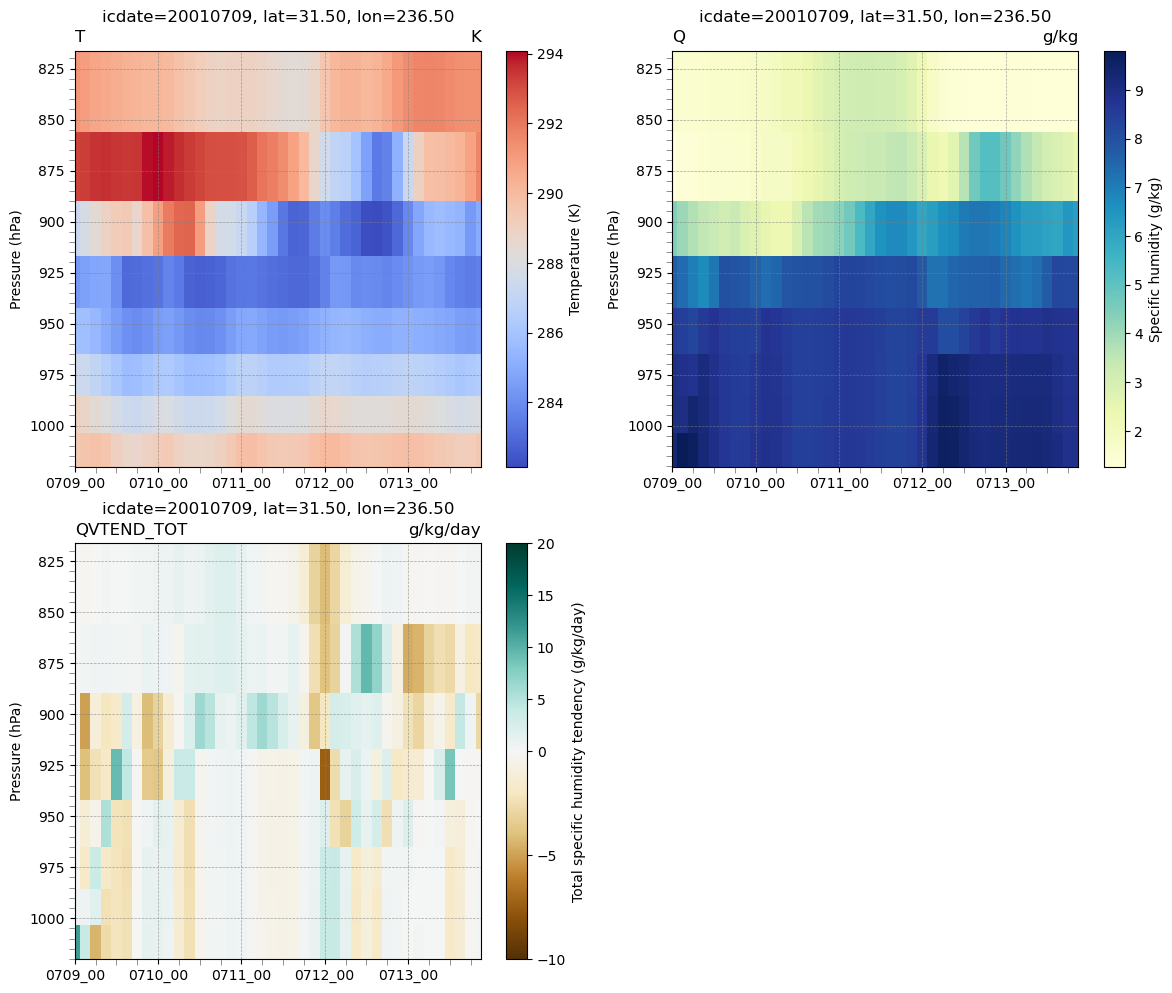

In [63]:
#--- set opt_in
title = f"icdate={icdate}, lat={lat_str}, lon={lon_str}"

opt_in = {
    "lev_select": "play", "lev_min": 800, "lev_max": 1100,
    #"lev_select": "Z3", "lev_max": 3000, "lev_min":0,
    "start_str": None, "end_str": None, 
    "title": title, 
    #--- for cn_time_lev and xy_series plots
    #"time_tick_major_interval":8, "time_tick_minor_number":3 ,
}

#--- set var)group
choice="112"
if (choice == "111"):
    # var_group set in plot_cn_time_level_panel
    var_group = "test"   
    
elif (choice == "112"):
    # user set var_group
    var_group = [
            ("state", "T"), 
            ("state", "Q"),         
            ("Qtend", "QVTEND_TOT"),
            ]

#--- plot
plot_cn_time_level_panel(icdate, lat, lon, var_group, opt_in)

## Plot xy_profile_Nv1t

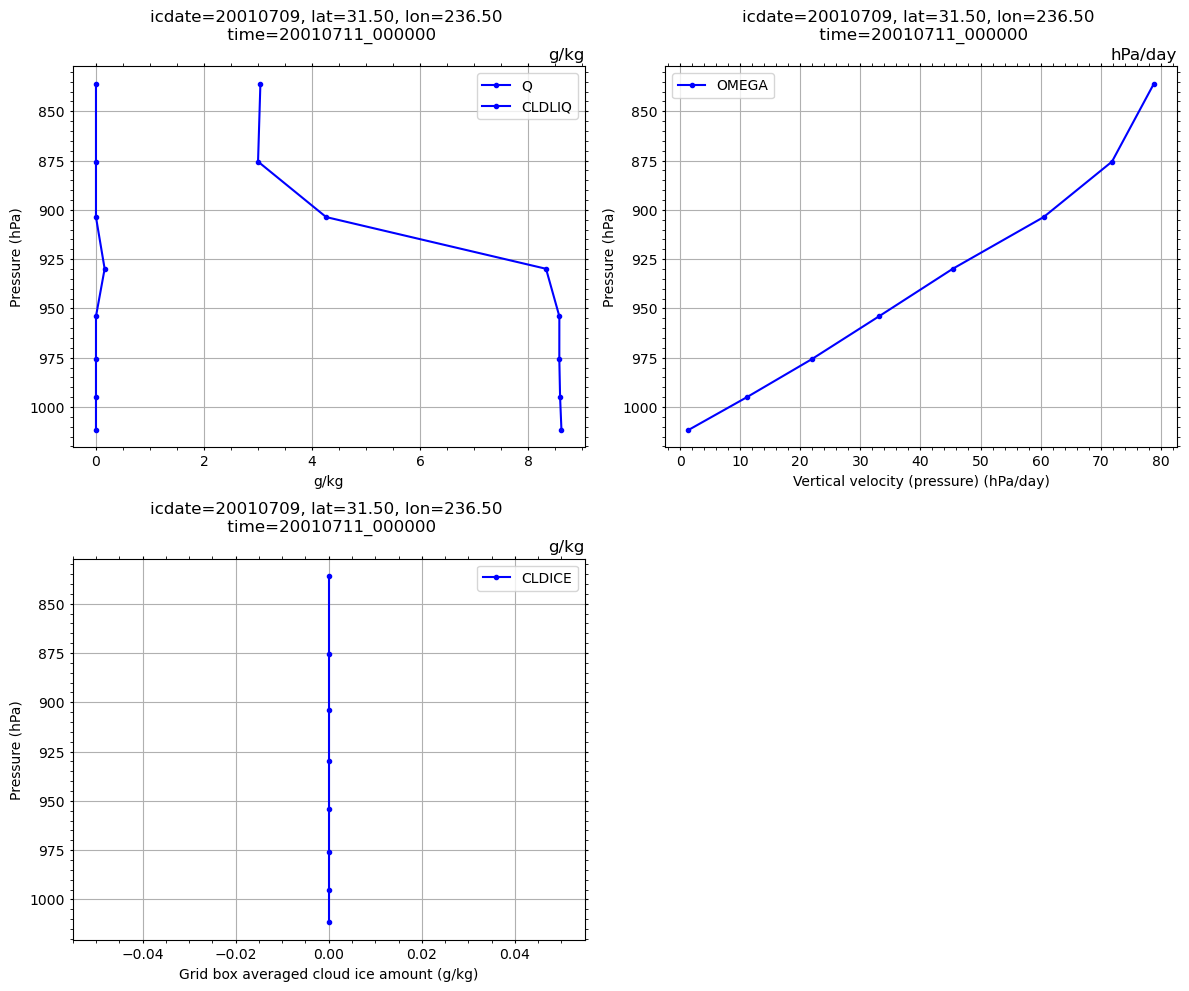

In [79]:
#--- set opt_in
start_str = "20010711_000000"
title = f"icdate={icdate}, lat={lat_str}, lon={lon_str} \n time={start_str}"

opt_in = {
    "lev_select": "play", "lev_min": 800, "lev_max": 1100,
    #"lev_select": "Z3", "lev_max": 3000, "lev_min":0,
    "start_str": start_str , "end_str":start_str, 
    "title": title, 
    #--- for cn_time_lev and xy_series plots
    #"time_tick_major_interval":8, "time_tick_minor_number":3 ,
}

#--- set var_group
choice="112"
if (choice == "111"):
    # var_group set in plot_cn_time_level_panel
    var_group = "test"   
    
elif (choice == "112"):
    # user set var_group
    var_group = [
            ("state", ["Q","CLDLIQ"]),
            ("state", ["OMEGA"]),
            ("state", ["CLDICE"]),
            ]

# plot
plot_xy_profile_Nv1t_panel(icdate, lat, lon, var_group, opt_in)

## Plot xy_profile_1vNt

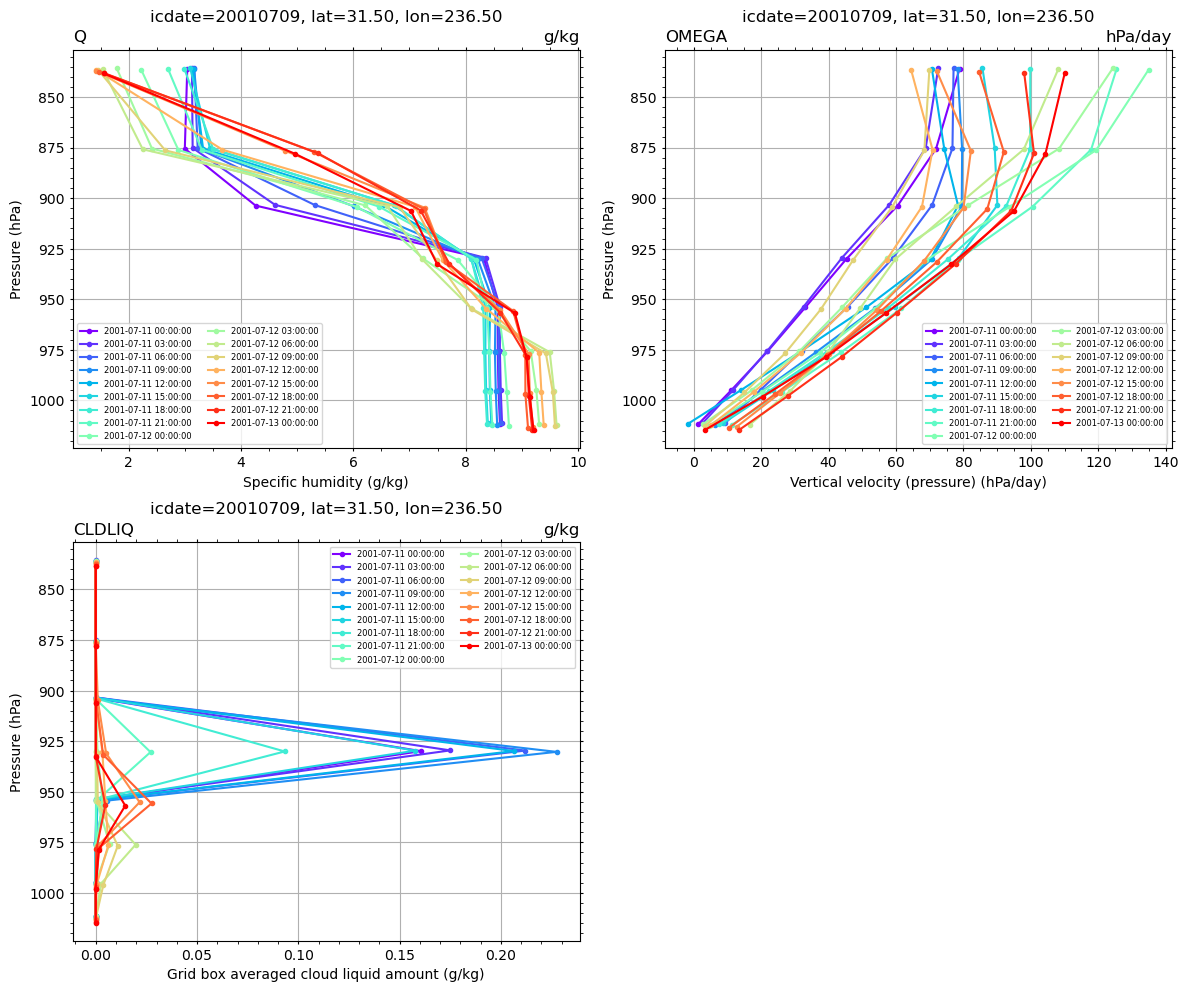

In [81]:
#--- set opt_in
start_str = "20010711_000000" ; end_str = "20010713_000000"
title = f"icdate={icdate}, lat={lat_str}, lon={lon_str}"

opt_in = {
    "lev_select": "play", "lev_min": 800, "lev_max": 1100,
    #"lev_select": "Z3", "lev_max": 3000, "lev_min":0,
    "start_str": start_str , "end_str":end_str, 
    "title": title, 
    "stride":1,
}

#--- var_group
choice="112"
if (choice == "111"):
    # var_group set in plot_cn_time_level_panel
    var_group = "test"   

elif (choice == "112"):
    # user set var_group
    var_group = [
            ("state", "Q"),
            ("state", "OMEGA"),
            ("state", "CLDLIQ"),
            ]

#--- plot
plot_xy_profile_1vNt_panel(icdate, lat, lon, var_group, opt_in)

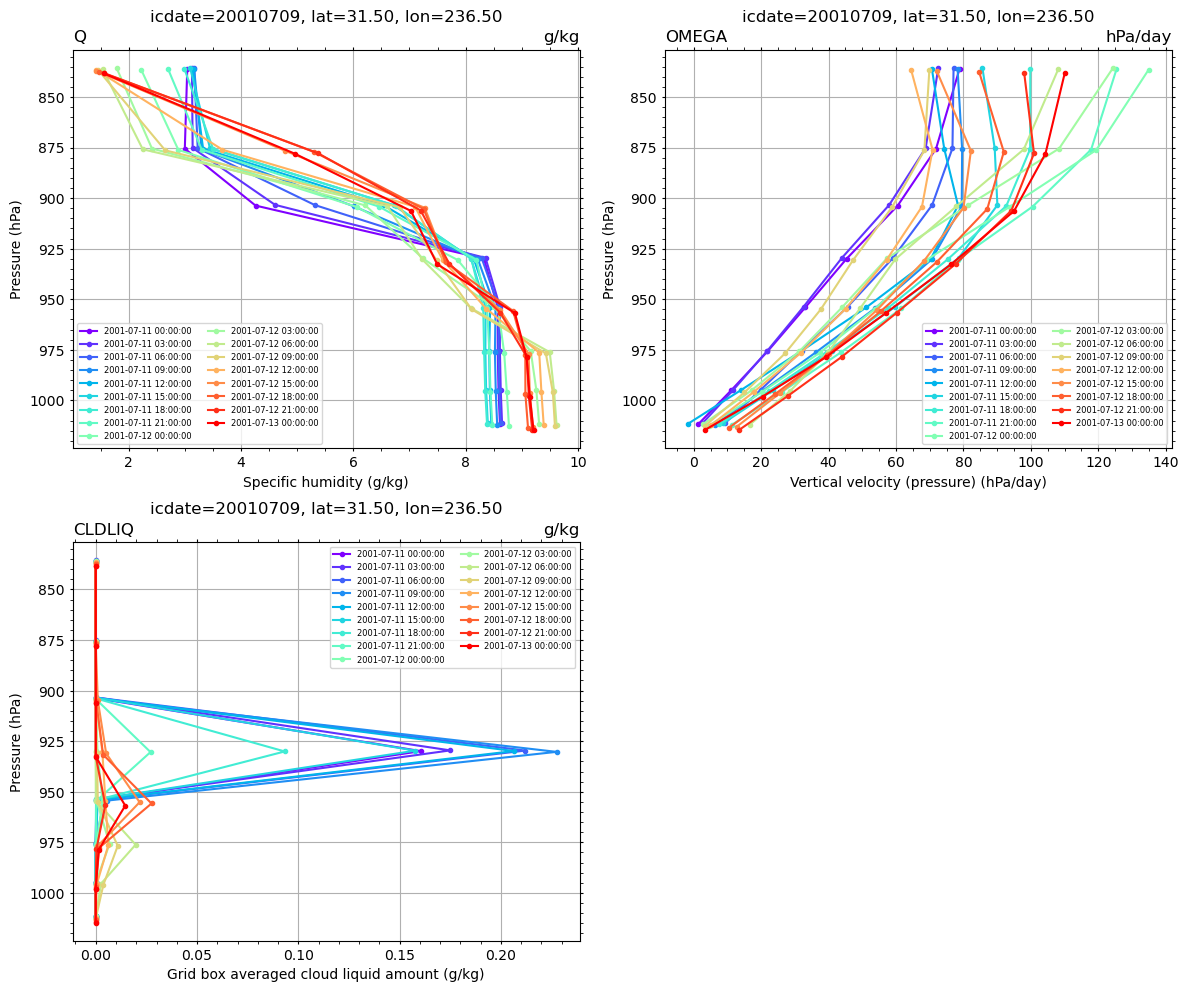

In [32]:
# select all time and lev
lev_select = "play" ; lev_max = 1100 ; lev_min = 800
#lev_select = "Z3" ; lev_max = 3000 ; lev_min = 0

start_str = "20010711_000000" ; end_str = "20010713_000000"
stride = 1

title = f"icdate={icdate}, lat={lat_str}, lon={lon_str}"

choice="112"
if (choice == "111"):
    # var_group set in plot_cn_time_level_panel
    var_group = "test"   

elif (choice == "112"):
    # user set var_group
    var_group = [
            ("state", "Q"),
            ("state", "OMEGA"),
            ("state", "CLDLIQ"),
            ]

plot_xy_profile_1vNt_panel(icdate, lat, lon, var_group, 
                            start_str=start_str, end_str=end_str, stride=stride, 
                            lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
                            title=title)

## Plot time_series_Nv

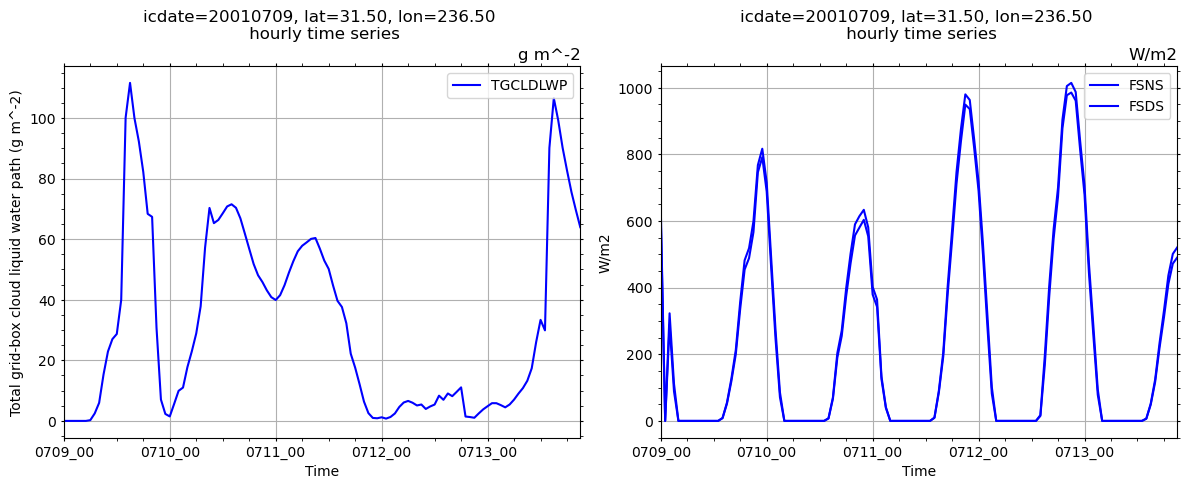

In [33]:
# set variables for plotting
choice="112"
if (choice == "111"):
    # var_group set in plot_cn_time_level_panel
    var_group = "test"   

elif (choice == "112"):
    # user set var_group
    var_group = [
            ("1d_time", ["TGCLDLWP"]),      
            ("1d_time", ["FSNS","FSDS"]),
            ]

# set time
start_str = None ; end_str=None ; time_interval = 24
#start_str = "20010711_000000" ; end_str = "20010713_000000" ; time_interval = 12

# set title
title = f"icdate={icdate}, lat={lat_str}, lon={lon_str} \n hourly time series"

# make panel plots
plot_xy_series_Nv_panel(icdate, lat, lon, var_group,
                        time_interval=time_interval, start_str=start_str, end_str=end_str, 
                        title=title)